## Methode STIT de Klatt et Lotz


Persistence of asymptotic variance under transport: \
from hyperfluctuation to stealthy hyperuniformity \

cf Page 6 du papier:
https://arxiv.org/pdf/2605.22803


 STIT tessellations = STable with respect to ITerations

In [21]:
#pip install blue_sampler

In [22]:
import blue_sampler as blue
import numpy as np
import matplotlib.pyplot as plt
from blue_sampler.datasets import generate_dataset

In [ ]:
def centroids(x):
    """
    Compute the barycenters of a batch of quadrilaterals.

    Parameters
    ----------
    x : ndarray, shape (batch, 4, 2)
        Batch of quadrilaterals represented by their four vertices.

    Returns
    -------
    ndarray, shape (batch, 2)
        Coordinates of the barycenter of each quadrilateral.
    """
    return x.mean(axis=1)


def solve_moment_polygons(x, p=3):
    """
    Generate hyperuniform points by matching geometric moments of polygons.

    The generated points satisfy moment equalities up to order ``p - 1``
    with respect to the original polygons.

    Parameters
    ----------
    x : ndarray, shape (N, 4, 2)
        Collection of N quadrilaterals forming an even partition of space.
        Moments are computed from the continuous geometric domains.

    p : int, optional
        Maximum moment order to match (default: 3).

    Returns
    -------
    ndarray, shape (N, m, 2)
        Generated points matching the polygon moments.
    """
    return blue.tessel2points(x, p)

def show_polygons(ax, tessels):
    n = len(tessels)
    cmap = plt.cm.YlGnBu

    x = tessels[:, :, 0]
    y = tessels[:, :, 1]
    x_next = np.roll(x, -1, axis=1)
    y_next = np.roll(y, -1, axis=1)
    areas_inv = 1/np.abs(0.5 * np.sum(x * y_next - x_next * y, axis=1))
    areas_inv2 = (areas_inv)**2
    areas_inv2 = (areas_inv2/areas_inv2.mean()+0.03).clip(max = 1.0)

    for i, quad in enumerate(tessels):
        color = cmap(0.2 + 0.8 * (i / n))
        alpha = areas_inv2[i]

        qloop = np.vstack([quad, quad[0]])
        ax.fill(
            qloop[:, 0], qloop[:, 1],
            color=color,
            alpha=alpha,
            edgecolor="#FFFFFF",
            linewidth=1.2,
            zorder=1
        )
    return ax

def show_clusters(ax, clusters):
    n = len(clusters)
    cmap = plt.cm.YlGnBu

    for i, pts in enumerate(clusters):
        color = cmap(0.5 + 0.5 * (i / n))

        ax.scatter(
            pts[:, 0], pts[:, 1],
            s=18,
            color=color,
            alpha=0.9,
            edgecolors="#1A2B3C",
            linewidths=0.3,
            zorder=2
        )
    return ax

def show_result(tessels = None, points = None):
    # --- figure ---
    fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

    fond_clair = "#FAFAFA"
    fig.patch.set_facecolor(fond_clair)
    ax.set_facecolor(fond_clair)

    if tessels is not None:
        show_polygons(ax, tessels)
    if points is not None:
        show_clusters(ax, points)

    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

## fair STIT allow to sample 1 million tessels in a matter of seconds

here we will sample only 65 000 tessels

In [24]:
tessels = blue.sample_tessels(N = 2**16)

one cannot plot all the tessels (to slow). back merge allow to reverse a tesselation step, thus to plot a reasonable number of tessels

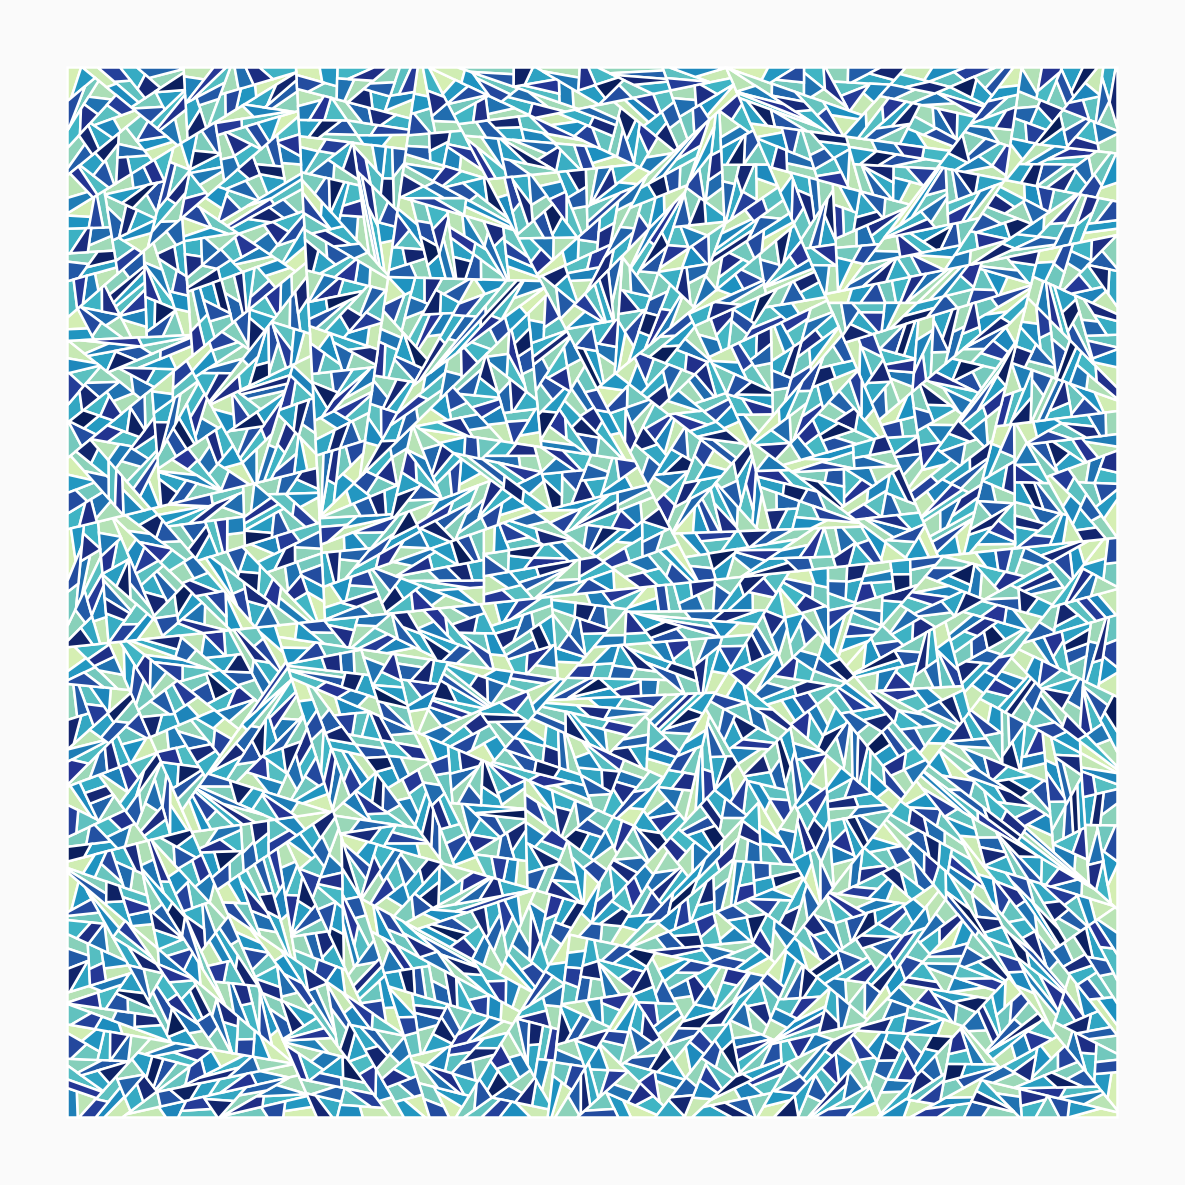

In [25]:
from blue_sampler.run.run_tessels import back_merge_tessels
sub_tessels = tessels
for _ in range(4):
    sub_tessels = back_merge_tessels(sub_tessels)
show_result(sub_tessels) #the full tesselation is much finer, but impossible to plot in a reasonable time

## Now we can sample points well distributed with respect to the tessels


Here we just sample points at the center of each tessel

(65536, 2)


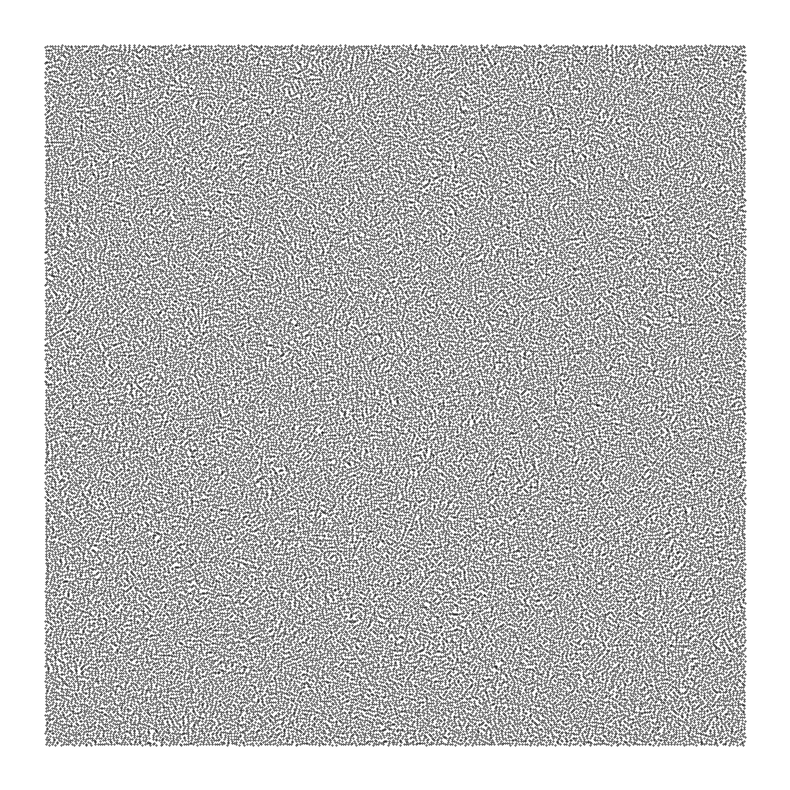

In [26]:
x_center = centroids(tessels)
print(x_center.shape)
blue.plot(x_center)

But one can also solve moment equation, eg solve moment up to order 2 (p = 3). slower but better results

(65536, 3, 2)


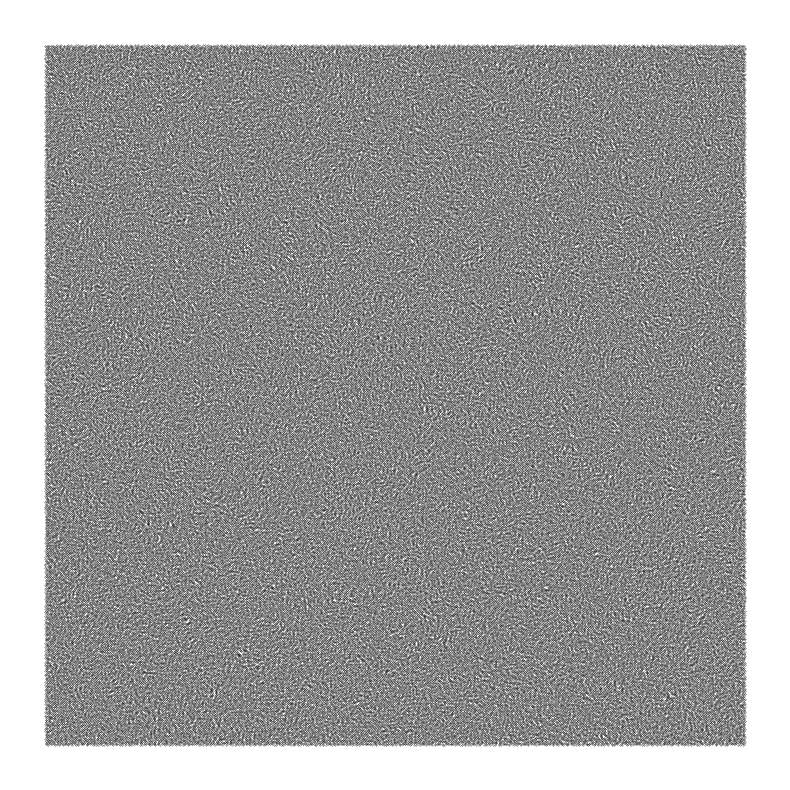

In [27]:
x_moment2 = solve_moment_polygons(tessels)
print(x_moment2.shape)
blue.plot(x_moment2)

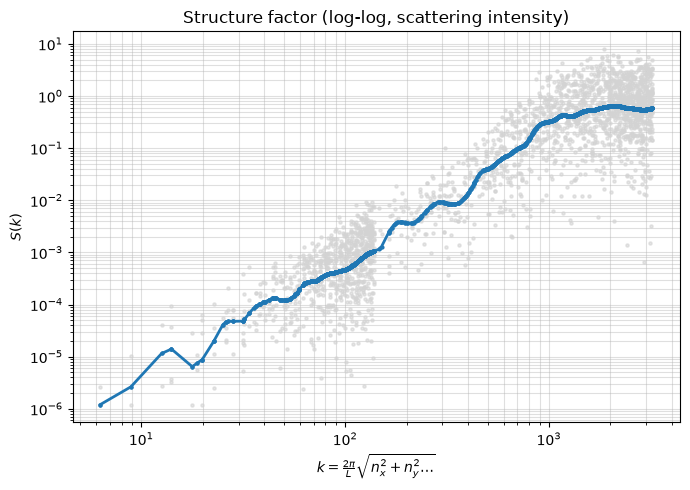

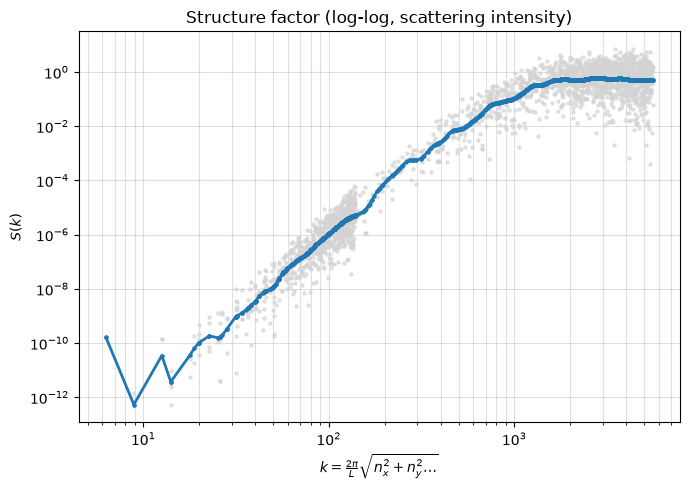

In [28]:
blue.plot_structure_factor(x_center)
blue.plot_structure_factor(x_moment2) #slower but better

## Tessels for adaptative sampling

In [30]:
targets = blue.generate_dataset(size = (2**12*100,2), dataset = "france", plot_data = False)
tessels = blue.sample_tessels(N=2**12, targets = targets)

source: squarenet.sampler from module squarenet
available datasets: {'realdata': ['barbara', 'lena', 'france', 'germany', 'everest'], 'synthetic': ['square', 'ball', 'ring', 'gaussian', 'spiky', 'holy', '4Dloop']}


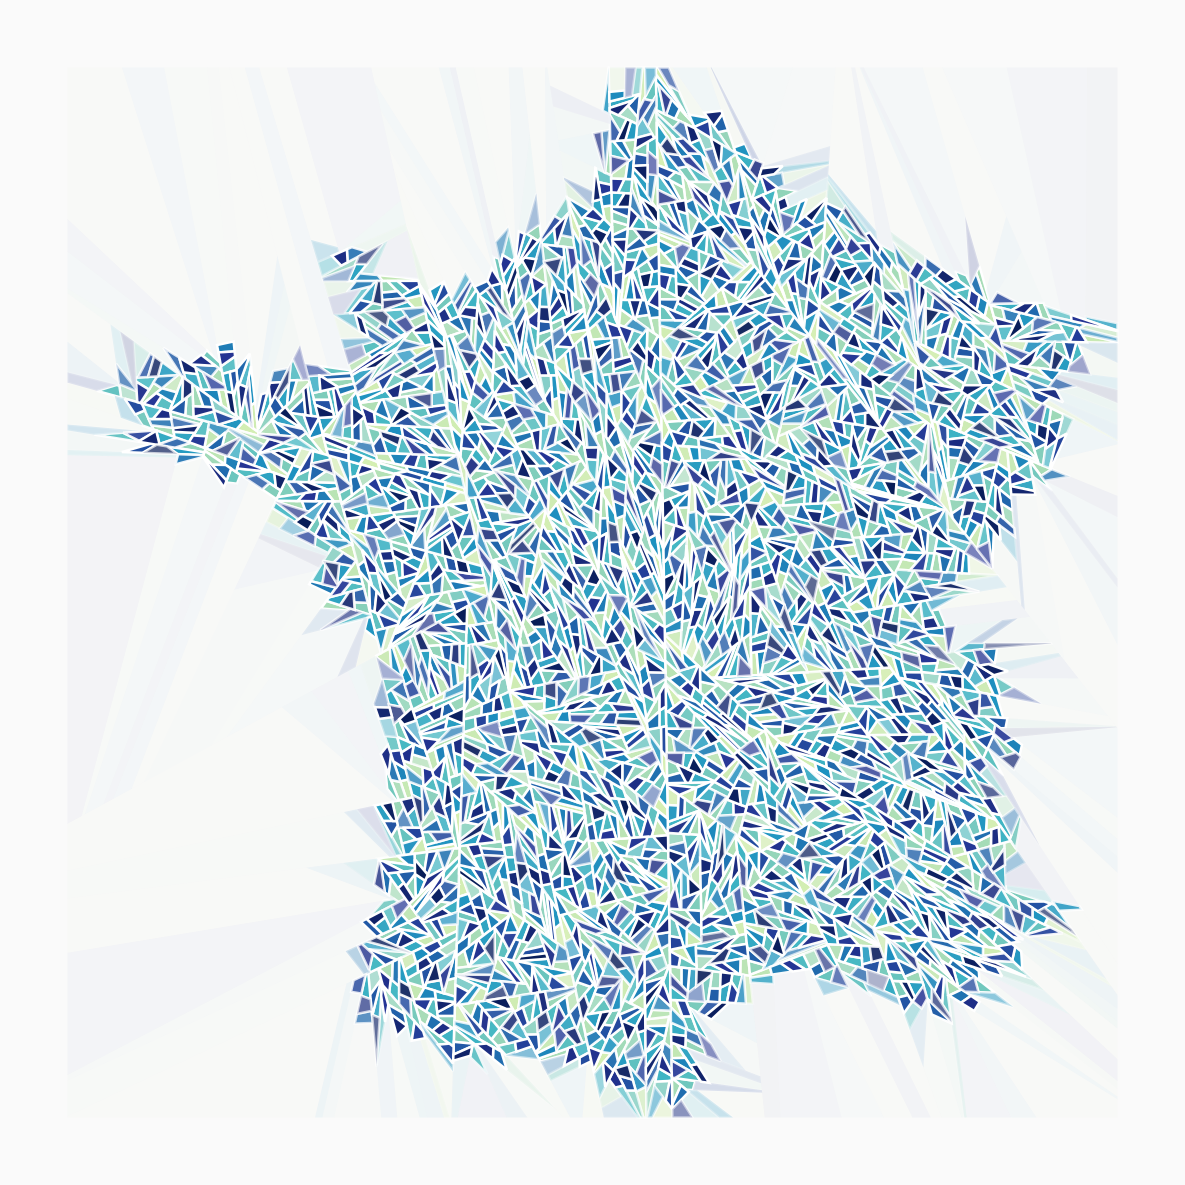

In [31]:
show_result(tessels)